In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
file = '../output/EqCond+Remove/summary_escape.dat'
#file = '../output/EqCond+Remove/summary_escape_Jeans.dat'

data = np.loadtxt(file, dtype=object, skiprows=1)

#mask = np.array([name[:2] == 'Ea' for name in data[:, 0]])
mask = np.array(['Io' in name for name in data[:, 0]])
mask = np.logical_and(mask, np.array(['CplusO=1e-2' in name for name in data[:, 0]]))
mask = np.logical_and(mask, np.array([name[-4:] == '0.59' for name in data[:, 0]]))
#mask = np.ones(len(data), dtype=bool)
print(np.sum(mask))

# lambdas = data[mask, 1].astype(float) for summary_escape_Jeans.dat
names = data[mask, 0].astype(str)
regime = data[mask, 1].astype(str)
escape_times = data[mask, 2].astype(float)

evap_mask = escape_times<1e15
evap_names = names[evap_mask]
evap_escape_times = escape_times[evap_mask]

for name, time in zip(evap_names, evap_escape_times):
    print(f'{np.log10(time):.2f}', name, regime[names==name])

17
10.95 Io_P0=1e6_Tint=100_CplusO=1e-2_CtoO=0.59 ['Jeans']
11.14 Io_P0=1e6_Tint=150_CplusO=1e-2_CtoO=0.59 ['Jeans']
1.80 Io_P0=1e6_Tint=200_CplusO=1e-2_CtoO=0.59 ['Energy-limited']
1.42 Io_P0=1e6_Tint=250_CplusO=1e-2_CtoO=0.59 ['Energy-limited']
12.14 Io_P0=1e7_Tint=100_CplusO=1e-2_CtoO=0.59 ['Jeans']
3.30 Io_P0=1e7_Tint=150_CplusO=1e-2_CtoO=0.59 ['Energy-limited']
2.80 Io_P0=1e7_Tint=200_CplusO=1e-2_CtoO=0.59 ['Energy-limited']
2.42 Io_P0=1e7_Tint=250_CplusO=1e-2_CtoO=0.59 ['Energy-limited']
12.03 Io_P0=1e7_Tint=50_CplusO=1e-2_CtoO=0.59 ['Jeans']
12.02 Io_P0=1e7_Tint=75_CplusO=1e-2_CtoO=0.59 ['Jeans']
9.15 Io_P0=1e7_Tint=125_CplusO=1e-2_CtoO=0.59 ['Hydrodynamic']
12.12 Io_P0=1e8_Tint=25_CplusO=1e-2_CtoO=0.59 ['Jeans']
13.19 Io_P0=1e8_Tint=50_CplusO=1e-2_CtoO=0.59 ['Jeans']
5.51 Io_P0=1e8_Tint=75_CplusO=1e-2_CtoO=0.59 ['Energy-limited']
6.09 Io_P0=1e8_Tint=100_CplusO=1e-2_CtoO=0.59 ['Hydrodynamic']
4.62 Io_P0=1e8_Tint=125_CplusO=1e-2_CtoO=0.59 ['Energy-limited']
4.30 Io_P0=1e8_Tint=15

0
0


Text(0.5, 1.0, 'Escape Time Scale for all Earth Models')

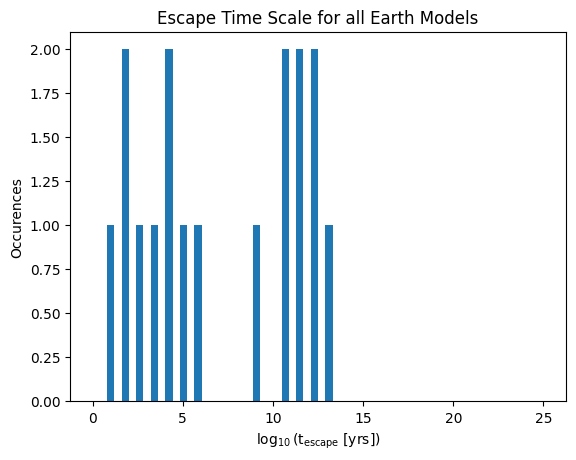

In [4]:
max_logt = 25
plt.hist(np.log10(escape_times[escape_times!=np.inf]), bins=31, range=(0, max_logt), width=0.4)
print(np.sum(np.log10(escape_times[escape_times!=np.inf])>max_logt))
print(np.sum(escape_times==np.inf))

plt.xlabel(r'$\log_{10}$(t$_\mathrm{escape}$ [yrs])')
plt.ylabel('Occurences')
plt.title('Escape Time Scale for all Earth Models')

['Energy-limited' 'Hydrodynamic' 'Jeans']
{'Jeans': 7, 'Energy-limited': 8, 'Hydrodynamic': 2}


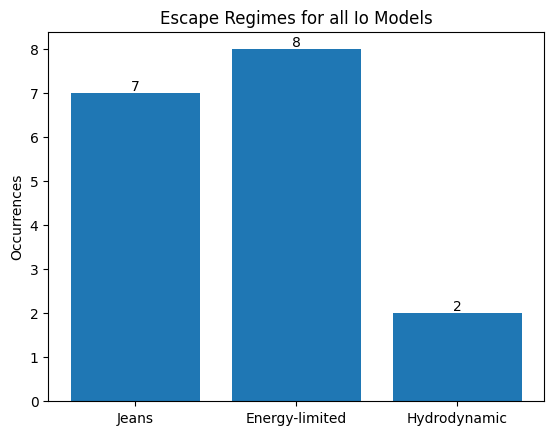

In [5]:
regimes = ['Jeans', 'Energy-limited', 'Hydrodynamic']
print(np.unique(regime))
plot_dict = {}
for r in regimes:
    plot_dict[r] = np.sum(regime == r)

print(plot_dict)

bar = plt.bar(plot_dict.keys(), plot_dict.values())
plt.bar_label(bar)
plt.ylabel('Occurrences')
plt.title('Escape Regimes for all Io Models')
plt.show()

Text(0.5, 1.0, 'Jeans Escape Parameters for all Earth Models')

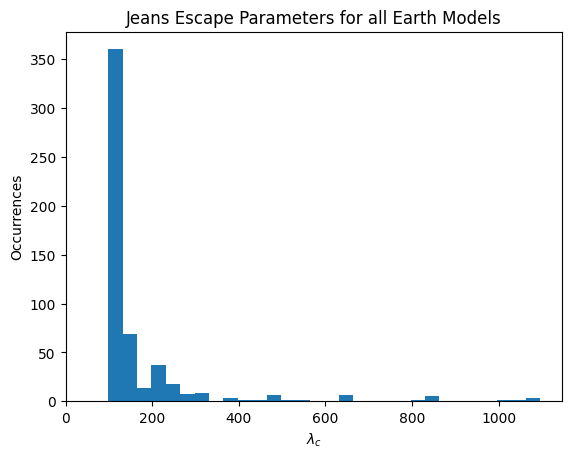

In [ ]:
# plt.hist(np.log10(lambdas), bins=30)
# plt.xlabel(r'$\log_{10}(\lambda_c)$')

plt.hist(lambdas, bins=30)
plt.xlabel(r'$\lambda_c$')
plt.xlim(0,None)

plt.ylabel('Occurrences')
plt.title('Jeans Escape Parameters for all Earth Models')